# Prompt Bootstrapping with Human Feedback

Prompt engineering isn't always the most fun, especially when it comes to tasks where metrics are hard to defined. Crafting a prompt is often an iterative process, and it can be hard to get over the initial "cold start problem" of creating good prompts and datasets.

Turns out LLMs can do a [decent job at prompt engineering](https://arxiv.org/abs/2211.01910), especially when incorporating human feedback on representative data. For lack of a better term, I'll call this form of prompt optimization "Prompt Bootstrapping", since it iteratively refines a prompt via instruction tuning distilled from human feedback. Below is an overview of the process.

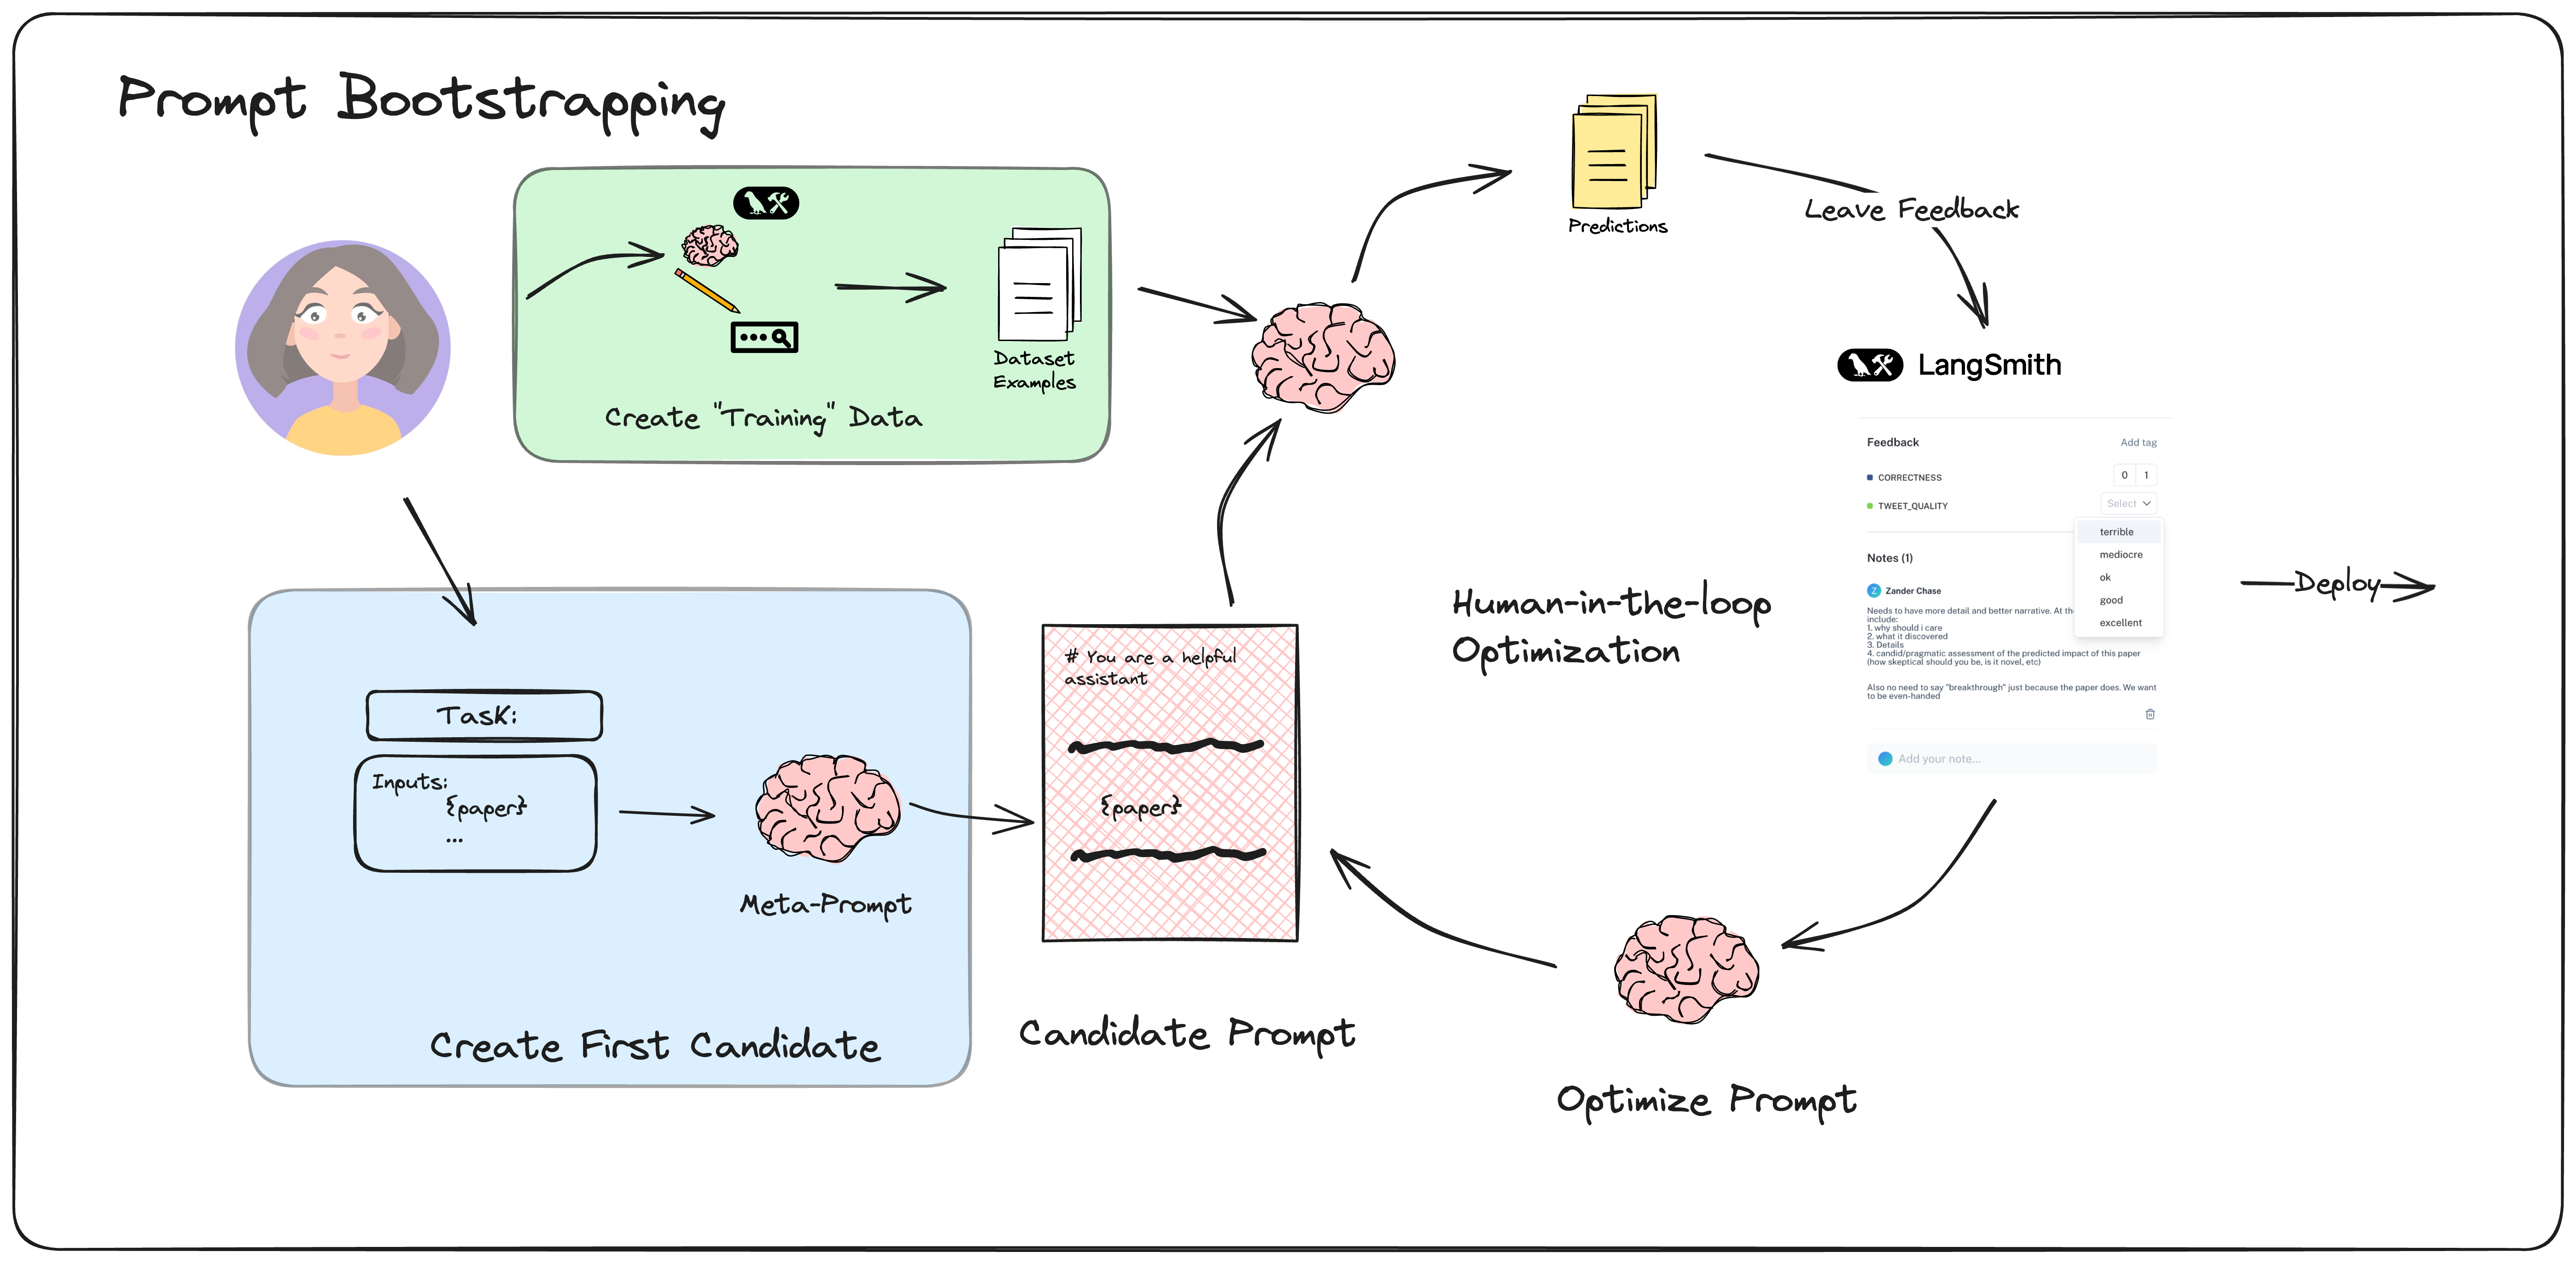

LangSmith makes this this whole flow very easy. Let's give it a whirl!

This example is based on [@alexalbert's example Claude workflow](https://twitter.com/alexalbert__/status/1767258557039378511?s=20).

In [17]:
import os
import ssl
import truststore

# Use macOS system trust store (includes corporate CA certs)
truststore.inject_into_ssl()

os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_TRACING_V2"] = "true"

# Groq client (OpenAI-compatible)
import openai
from langsmith.wrappers import wrap_openai

groq_client = wrap_openai(openai.Client(
    api_key=os.environ["GROQ_API_KEY"],
    base_url="https://api.groq.com/openai/v1",
    ))


In [18]:
from langsmith import Client

client = Client()

# 1. Pick a task

Let's say I want to write a tweet generator about academic papers, one that is catchy but not laden with too many buzzwords
or impersonal. Let's see if we can "optimize" a prompt without having to engineer it ourselves.

We will use the meta-prompt ([wfh/metaprompt](https://smith.langchain.com/hub/wfh/metaprompt)) from the Hub to generate our first prompt candidate to solve this task.

In [19]:
import time

task = (
    "Generate a tweet to market an academic paper or open source project. It should be"
    " well crafted but avoid gimicks or over-reliance on buzzwords."
)

# Inline metaprompt (replaces hub.pull("wfh/metaprompt"))
META_PROMPT = """Given the following task description, generate a detailed prompt that will guide an AI to complete the task effectively.

Task: {task}

The prompt should use these input variables: {input_variables}

Generate a prompt wrapped in <Instructions> tags. The prompt should:
1. Clearly define the role and objective
2. Provide specific guidelines for the output format
3. Include any necessary constraints
4. Be detailed enough to produce high-quality results"""


def get_instructions(gen: str):
    if "<Instructions>" in gen and "</Instructions>" in gen:
        return gen.split("<Instructions>")[1].split("</Instructions>")[0]
    return gen  # Return full text if tags not found


def meta_prompter_invoke(task: str, input_variables: str):
    time.sleep(3)
    response = groq_client.chat.completions.create(
        model="llama-3.1-8b-instant",
        temperature=0.7,
        messages=[
            {"role": "user", "content": META_PROMPT.format(task=task, input_variables=input_variables)}
        ]
    )
    return get_instructions(response.choices[0].message.content)

In [20]:
recommended_prompt = meta_prompter_invoke(
    task=task,
    input_variables="{paper}",
)
print(recommended_prompt)

<Instructions>

**Objective:**
Generate a tweet to market an academic paper or open source project, effectively conveying its significance and value to a target audience of academics, researchers, and professionals.

**Input Variable:**
{paper} - This variable represents the title of the academic paper or open source project to be marketed.

**Output Format:**
A tweet with the following characteristics:

1. **Length:** 280 characters or less
2. **Format:** A concise, informative, and engaging tweet that includes the title of the paper or project and a brief description of its key findings or features.
3. **Tone:** Formal and professional, but approachable and accessible to a general audience.

**Guidelines:**

1. **Clearly convey the significance:** Highlight the paper's or project's key contributions, innovations, or impact on the field.
2. **Be concise and focused:** Avoid using jargon or overly technical language, and focus on the main takeaway or benefit of the paper or project.
3.

OK so it's a fine-not-great prompt. Let's see how it does!

## 2. Dataset

For some tasks you can generate them yourselves. For our notebook, we have created a 10-datapoint dataset of some scraped ArXiv papers.

In [21]:
from itertools import islice
from langchain_community.utilities.arxiv import ArxivAPIWrapper

wrapper = ArxivAPIWrapper(doc_content_chars_max=3000)  # Truncate to stay within Groq limits
docs = list(islice(wrapper.lazy_load("Self-Replicating Language model Agents"), 5))  # 5 papers
print(f"Loaded {len(docs)} papers")

Loaded 3 papers


In [22]:
ds_name = "Tweet Generator"
try:
    ds = client.read_dataset(dataset_name=ds_name)
    print(f"Dataset '{ds_name}' already exists, skipping creation.")
except Exception:
    ds = client.create_dataset(dataset_name=ds_name)
    client.create_examples(
        inputs=[{"paper": doc.page_content} for doc in docs], dataset_id=ds.id
    )
    print(f"Created dataset '{ds_name}' with {len(docs)} examples.")

Created dataset 'Tweet Generator' with 3 examples.


## 3. Predict

We will refrain from defining metrics for now (it's quite subjective). Instead we will run the first version of the generator against the dataset and manually review + provide feedback on the results.

In [23]:
from langsmith import traceable


def parse_tweet(response: str):
    try:
        return response.split("<tweet>")[1].split("</tweet>")[0].strip()
    except:
        return response.strip()


def create_tweet_generator(prompt_str: str):
    @traceable(run_type="chain", name="tweet_generator")
    def generate(inputs: dict) -> dict:
        paper = inputs["paper"][:3000]  # Truncate for Groq limits
        time.sleep(3)
        response = groq_client.chat.completions.create(
            model="llama-3.1-8b-instant",
            temperature=0.7,
            messages=[
                {"role": "system", "content": prompt_str},
                {"role": "user", "content": paper}
            ]
        )
        tweet = parse_tweet(response.choices[0].message.content)
        return {"output": tweet}
    return generate


tweet_generator = create_tweet_generator(recommended_prompt)

# Example
prediction = tweet_generator({"paper": docs[0].page_content})
print(prediction["output"])

Here's a tweet to market the academic paper or open source project:

"Introducing CoALA: Cognitive Architectures for Language Agents! Our new framework organizes the emerging field of language agents & outlines a path towards language-based general intelligence. Read the full paper in Transactions on Machine Learning Research (02/2024) to discover how CoALA is changing the game in AI research. #LanguageAgents #CognitiveScience #ArtificialIntelligence"


In [24]:
from langsmith.evaluation import evaluate

def predict_tweet(example: dict) -> dict:
    return tweet_generator(example)

res = evaluate(
    predict_tweet,
    data=ds_name,
    experiment_prefix="tweet-gen-v1",
    max_concurrency=1,
)
project_name_v1 = res.experiment_name
print(f"Experiment: {project_name_v1}")

View the evaluation results for experiment: 'tweet-gen-v1-4029cf1c' at:
https://smith.langchain.com/o/1ffcb2ed-904b-4ab3-885e-5e23637ec0c3/datasets/025eaa7a-df9c-4dea-a385-fba321b01b65/compare?selectedSessions=707eb187-c3f2-43d3-b484-a43b15eedcff




0it [00:00, ?it/s]

Experiment: tweet-gen-v1-4029cf1c


## 4. Label

Now, we will use an annotation queue to score + add notes to the results. We will use this to iterate on our prompt!

For this notebook, I will be logging two types of feedback:

`note`- freeform comments on the runs

`tweet_quality` - a 0-4 score of the generated tweet based on my subjective preferences

In [25]:
try:
    q = client.create_annotation_queue(name="Tweet Generator")
    print("Created annotation queue 'Tweet Generator'")
except Exception:
    # Queue may already exist
    queues = list(client.list_annotation_queues(name="Tweet Generator"))
    q = queues[0] if queues else client.create_annotation_queue(name="Tweet Generator")
    print("Using existing annotation queue 'Tweet Generator'")

Created annotation queue 'Tweet Generator'


In [26]:
run_ids = [r.id for r in client.list_runs(project_name=project_name_v1, execution_order=1)]
client.add_runs_to_annotation_queue(q.id, run_ids=run_ids)
print(f"Added {len(run_ids)} runs to annotation queue")

Added 3 runs to annotation queue


Now, go through the runs to label them. Return to this notebook when you are finished.

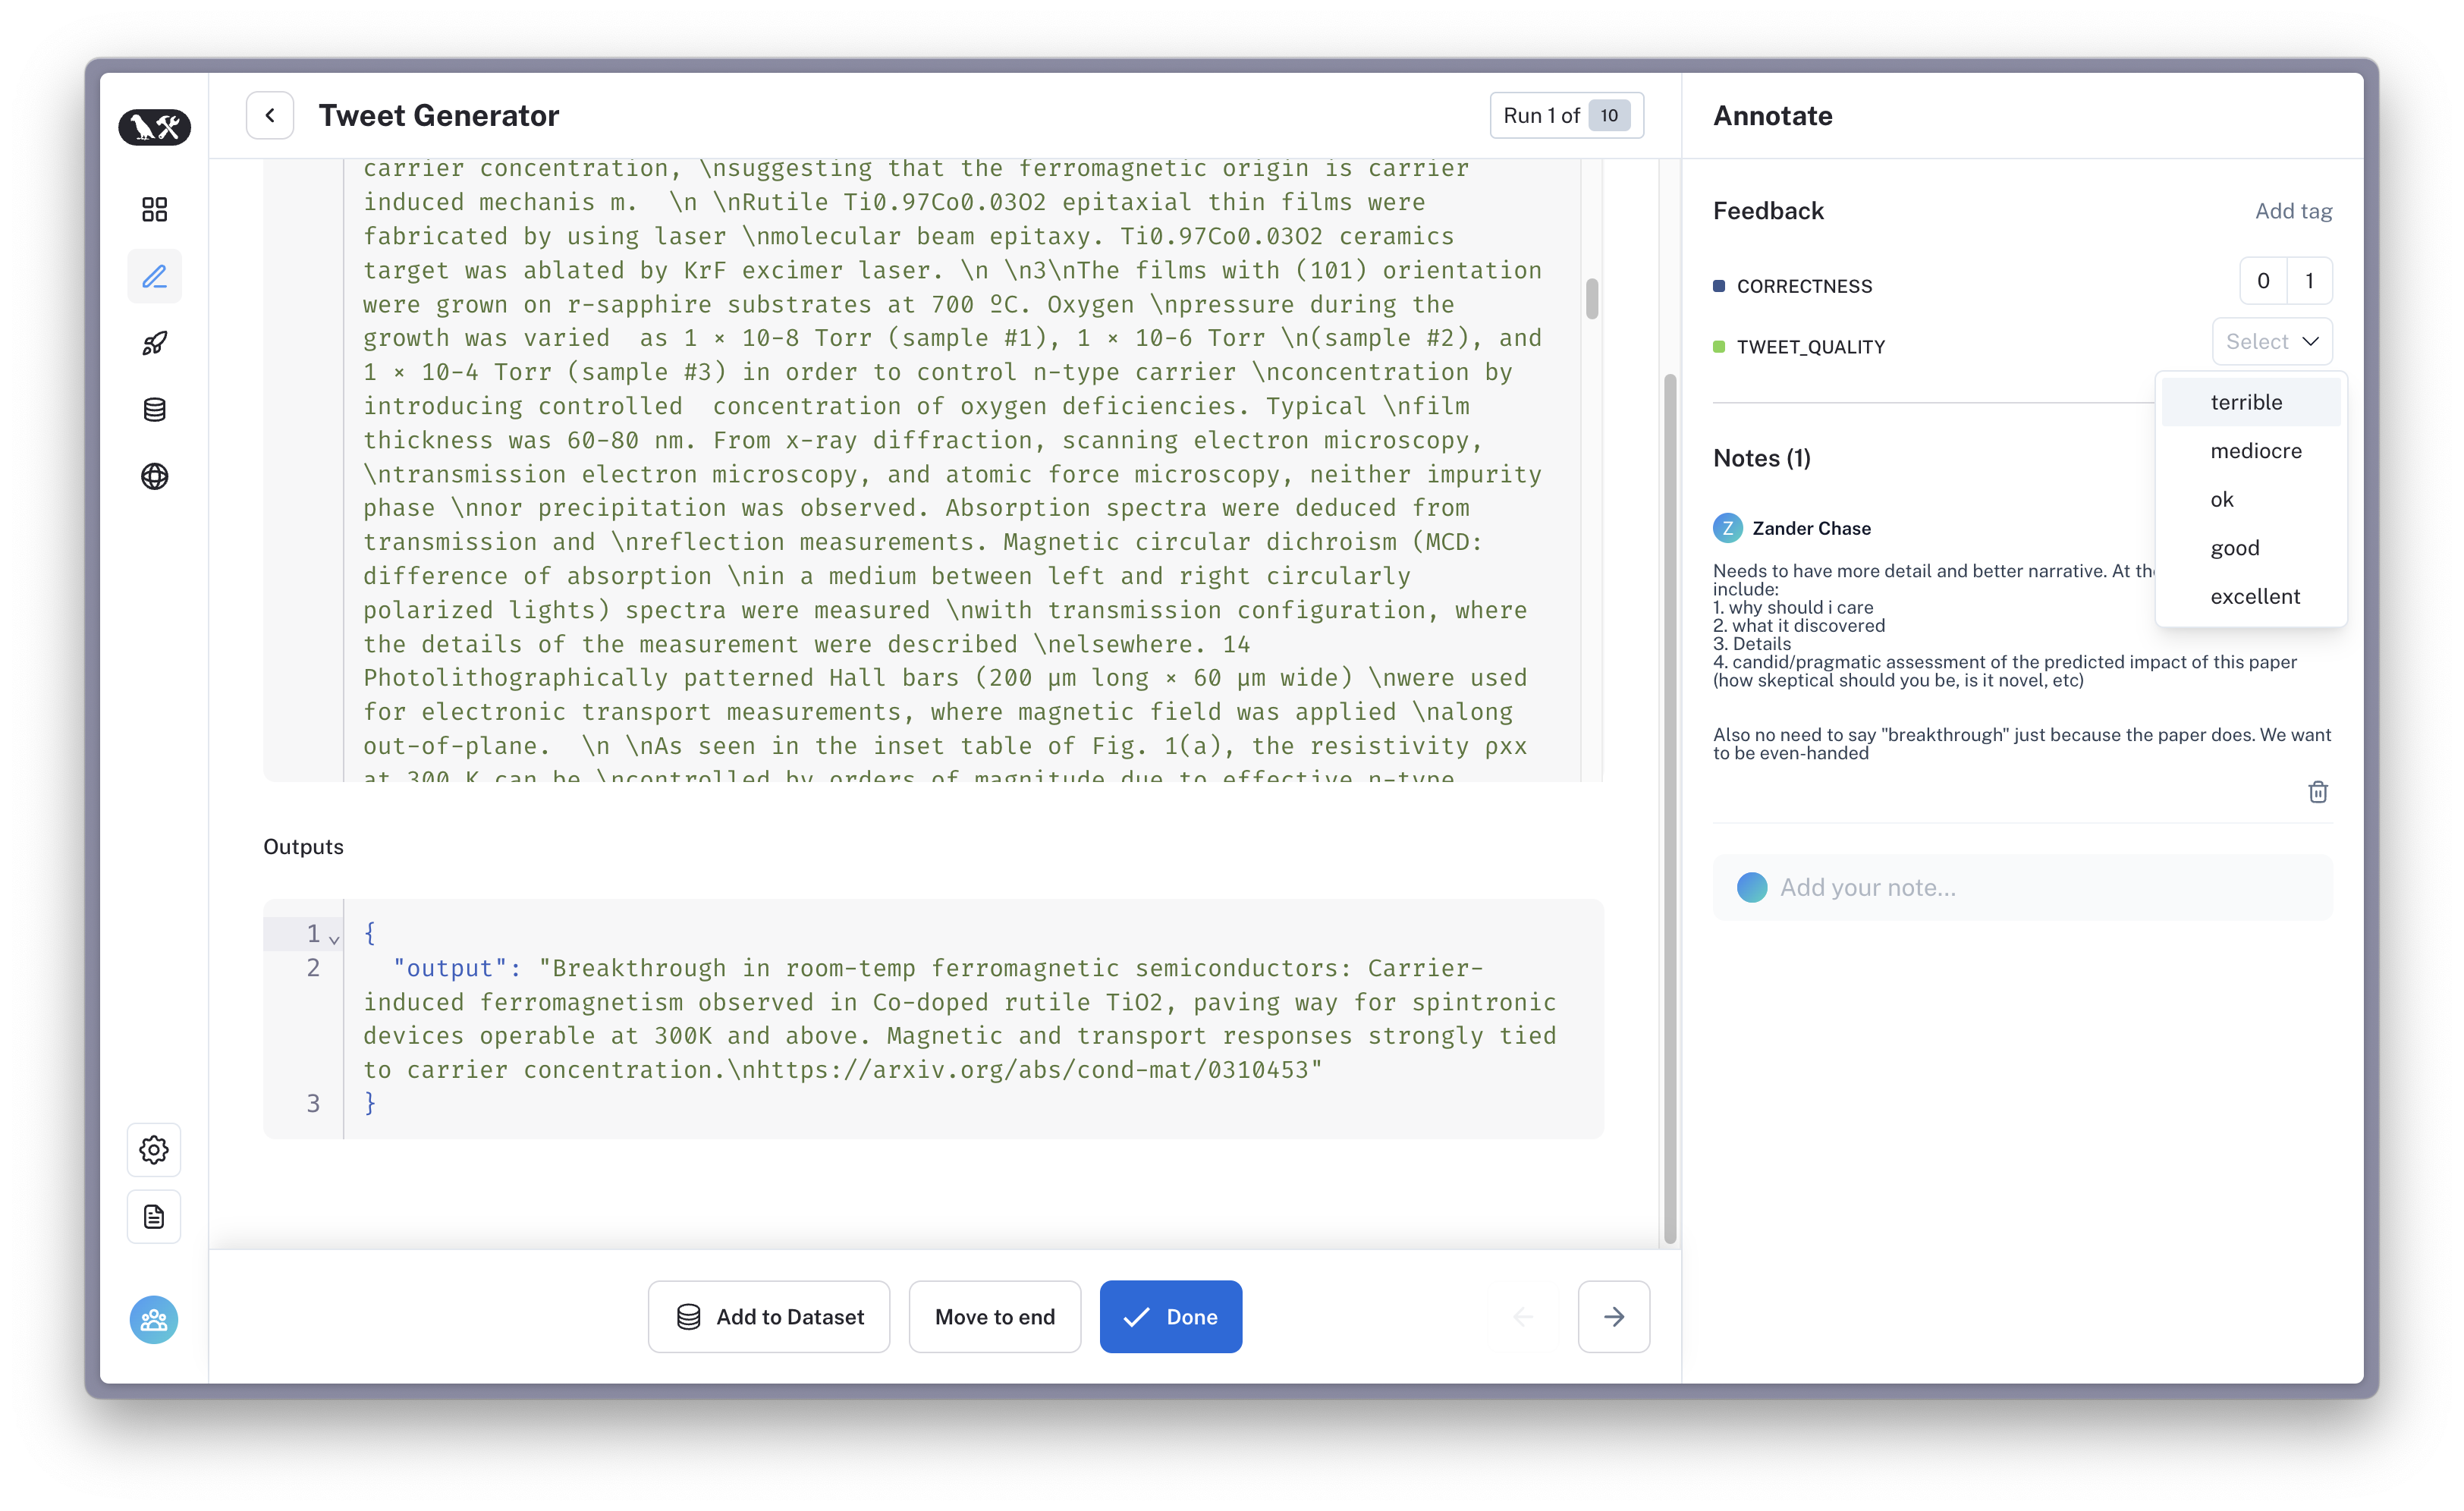

## 4. Update

With the human feedback in place, let's update the prompt and try again.

In [27]:
from collections import defaultdict


def format_feedback(single_feedback, max_score=4):
    if single_feedback.score is None:
        score = ""
    else:
        score = f"\nScore:[{single_feedback.score}/{max_score}]"
    comment = f"\n{single_feedback.comment}".strip()
    return f"""<feedback key={single_feedback.key}>{score}{comment}
</feedback>"""


def format_run_with_feedback(run, feedback):
    all_feedback = "\n".join([format_feedback(f) for f in feedback])
    return f"""<example>
<tweet>
{run.outputs["output"]}
</tweet>
<annotations>
{all_feedback}
</annotations>
</example>"""


def get_formatted_feedback(project_name: str):
    traces = list(client.list_runs(project_name=project_name, execution_order=1))
    feedbacks = defaultdict(list)
    for f in client.list_feedback(run_ids=[r.id for r in traces]):
        feedbacks[f.run_id].append(f)
    return [
        format_run_with_feedback(r, feedbacks[r.id])
        for r in traces
        if r.id in feedbacks
    ]

In [28]:
# Add some programmatic feedback so the optimizer has something to work with
runs = list(client.list_runs(project_name=project_name_v1, execution_order=1))
feedback_comments = [
    ("tweet_quality", 2, "Too many hashtags and buzzwords. Feels impersonal."),
    ("tweet_quality", 3, "Decent but could be punchier. Too formal."),
    ("tweet_quality", 1, "Generic and reads like a press release, not a tweet."),
]
for run, (key, score, comment) in zip(runs, feedback_comments):
    client.create_feedback(run.id, key=key, score=score, comment=comment)
    time.sleep(0.5)

formatted_feedback = get_formatted_feedback(project_name_v1)
print(f"Got feedback for {len(formatted_feedback)} runs")

Got feedback for 3 runs


LLMs are especially good at 2 things:
1. Generating grammatical text
2. Summarization

Now that we've left a mixture of scores and free-form comments, we can use an "optimizer prompt" ([wfh/optimizerprompt](https://smith.langchain.com/hub/wfh/optimizerprompt)) to incorporate the feedback into an updated prompt.


In [29]:
# Inline optimizer prompt (replaces hub.pull("wfh/optimizerprompt"))
OPTIMIZER_PROMPT = """You are a prompt optimization expert. Given a current prompt and annotated predictions with human feedback, 
generate an improved version of the prompt that addresses the feedback.

Current prompt:
{current_prompt}

Annotated predictions with human feedback:
{annotated_predictions}

Analyze the feedback carefully and generate an improved prompt that:
1. Addresses specific criticisms in the feedback
2. Maintains what works well (high-scored examples)
3. Is clear and specific

Wrap your improved prompt in <improved_prompt> tags."""


def extract_new_prompt(gen: str):
    if "<improved_prompt>" in gen and "</improved_prompt>" in gen:
        return gen.split("<improved_prompt>")[1].split("</improved_prompt>")[0].strip()
    return gen.strip()


def optimize_prompt(current_prompt: str, annotated_predictions: str):
    time.sleep(3)
    response = groq_client.chat.completions.create(
        model="llama-3.1-8b-instant",
        temperature=0.7,
        messages=[
            {"role": "user", "content": OPTIMIZER_PROMPT.format(
                current_prompt=current_prompt,
                annotated_predictions=annotated_predictions
            )}
        ]
    )
    return extract_new_prompt(response.choices[0].message.content)

In [30]:
current_prompt = recommended_prompt
new_prompt = optimize_prompt(
    current_prompt=current_prompt,
    annotated_predictions="\n\n".join(formatted_feedback).strip(),
)

In [31]:
print("Original Prompt\n\n" + current_prompt)
print("*" * 80 + "\nNew Prompt\n\n" + new_prompt)

Original Prompt

<Instructions>

**Objective:**
Generate a tweet to market an academic paper or open source project, effectively conveying its significance and value to a target audience of academics, researchers, and professionals.

**Input Variable:**
{paper} - This variable represents the title of the academic paper or open source project to be marketed.

**Output Format:**
A tweet with the following characteristics:

1. **Length:** 280 characters or less
2. **Format:** A concise, informative, and engaging tweet that includes the title of the paper or project and a brief description of its key findings or features.
3. **Tone:** Formal and professional, but approachable and accessible to a general audience.

**Guidelines:**

1. **Clearly convey the significance:** Highlight the paper's or project's key contributions, innovations, or impact on the field.
2. **Be concise and focused:** Avoid using jargon or overly technical language, and focus on the main takeaway or benefit of the pap

## 5. Repeat!

Now that we have an "upgraded" prompt, we can test it out again and repeat until we are satisfied with the result.

If you find the prompt isn't converging to something you want, you can manually update the prompt (you are the optimizer in this case) and/or be more explicit in your free-form note feedback.

In [32]:
tweet_generator = create_tweet_generator(new_prompt)

updated_results = evaluate(
    predict_tweet,
    data=ds_name,
    experiment_prefix="tweet-gen-v2",
    max_concurrency=1,
)
project_name_v2 = updated_results.experiment_name
print(f"Experiment: {project_name_v2}")

View the evaluation results for experiment: 'tweet-gen-v2-d9afef7f' at:
https://smith.langchain.com/o/1ffcb2ed-904b-4ab3-885e-5e23637ec0c3/datasets/025eaa7a-df9c-4dea-a385-fba321b01b65/compare?selectedSessions=81f9ed99-b2d0-4a9c-be21-ca4959fed6f2




0it [00:00, ?it/s]

Experiment: tweet-gen-v2-d9afef7f


In [33]:
run_ids = [r.id for r in client.list_runs(project_name=project_name_v2, execution_order=1)]
client.add_runs_to_annotation_queue(q.id, run_ids=run_ids)
print(f"Added {len(run_ids)} runs to annotation queue")

Added 3 runs to annotation queue


Then review/provide feedback/repeat.

Once you've provided feedback, you can continue here:

In [34]:
# Add feedback for v2 runs
runs_v2 = list(client.list_runs(project_name=project_name_v2, execution_order=1))
feedback_v2 = [
    ("tweet_quality", 3, "Better tone but still a bit long. Shorten it."),
    ("tweet_quality", 4, "Good! Conversational and engaging."),
    ("tweet_quality", 3, "Improved but could use a hook at the start."),
]
for run, (key, score, comment) in zip(runs_v2, feedback_v2):
    client.create_feedback(run.id, key=key, score=score, comment=comment)
    time.sleep(0.5)

formatted_feedback = get_formatted_feedback(project_name_v2)
print(f"Got feedback for {len(formatted_feedback)} runs")

Got feedback for 3 runs


In [35]:
# Swap them out
current_prompt = new_prompt
new_prompt = optimize_prompt(
    current_prompt=current_prompt,
    annotated_predictions="\n\n".join(formatted_feedback).strip(),
)

In [36]:
print("Previous Prompt\n\n" + current_prompt)
print("*" * 80 + "\nNew Prompt\n\n" + new_prompt)

Previous Prompt

<improved_prompt>

**Objective:**
Generate a concise and engaging tweet to market an academic paper or open-source project, effectively conveying its significance and value to a target audience of academics, researchers, and professionals.

**Input Variable:**
{paper} - This variable represents the title of the academic paper or open-source project to be marketed.

**Output Format:**
A tweet with the following characteristics:

1. **Length:** 280 characters or less
2. **Format:** A clear, concise, and engaging tweet that includes the title of the paper or project and a brief description of its key findings or features.
3. **Tone:** Formal and professional, but approachable and accessible to a general audience.

**Guidelines:**

1. **Clearly convey the significance:** Highlight the paper's or project's key contributions, innovations, or impact on the field.
2. **Be concise and focused:** Avoid using jargon or overly technical language, and focus on the main takeaway or 

## Conclusion

Congrats! You've "optimized" a prompt on a subjective task using human feedback and an automatic prompt engineer flow. LangSmith makes it easy to score and improve LLM systems even when it is hard to craft a hard metric.

You can push the optimized version of your prompt to the hub (here and in future iterations) to version each change.

In [37]:
# Hub push not available - just print the final optimized prompt
print("Final optimized prompt saved in 'new_prompt' variable:")
print(new_prompt)

Final optimized prompt saved in 'new_prompt' variable:
<improved_prompt>

**Objective:**
Generate a concise and engaging tweet to market an academic paper or open-source project, effectively conveying its significance and value to a target audience of academics, researchers, and professionals.

**Input Variable:**
{paper} - This variable represents the title of the academic paper or open-source project to be marketed.

**Output Format:**
A tweet with the following characteristics:

1. **Length:** 280 characters or less
2. **Format:** A clear, concise, and engaging tweet that includes the title of the paper or project and a brief description of its key findings or features.
3. **Tone:** Formal and professional, but approachable and accessible to a general audience.

**Guidelines:**

1. **Clearly convey the significance:** Highlight the paper's or project's key contributions, innovations, or impact on the field.
2. **Be concise and focused:** Avoid using jargon or overly technical langua

#### Extensions:

We haven't optimized the meta-prompts above - feel free to make them your own by forking and updating them!
Some easy extensions you could try out include:
1. Including the full history of previous prompts and annotations (or most recent N prompts with feedback) in the "optimizer prompt" step. This may help it better converge (especially if you're using a small dataset)
2. Updating the optimizer prompt to encourage usage of few-shot examples, or to encourage other prompting tricks.
3. Incorporating an LLM judge by including the annotation few-shot examples and instructing it to critique the generated outputs: this could help speed-up the human annotation process.
4. Generating and including a validation set (to avoid over-fitting this training dataset)